In [1]:
# Active Learning with MLP, Random Forest, SGD
# Includes: Random Sampling, Least Confidence, MC Dropout, RF & SGD (Uncertainty Sampling)
# Runs 5 seeds with 5-fold CV, Plots Mean ± SD, Computes Learning Efficiency and Test Set Accuracy

In [18]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
import random

In [19]:
# ------------------------
# Configuration
# ------------------------
seeds = [0, 2, 4, 10, 20]              # Random seeds to average results
init_frac = 0.2                      # Initial labeled fraction
max_frac = 0.5                       # Max labeled fraction
step = 5                             # Samples queried per round
cv_folds = 5                         # CV folds
n_mc_passes = 20                     # MC-Dropout forward passes


In [20]:
# ------------------------
# Load & Preprocess Data
# ------------------------
print("Loading and preprocessing data...")
df = pd.read_csv("vc_mutant_data.csv", header=None)
X = df.iloc[:, :-1].values
y = np.array(df.iloc[:, -1].values)

le = LabelEncoder()
y = le.fit_transform(y)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split off a test set (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


df.head()

Loading and preprocessing data...


,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,512
0,0.052671,-0.170843,0.127665,-0.157065,0.149449,-0.405221,-0.015877,1.019597,0.306551,0.057538,...,1.002674,0.837392,1.133352,-0.255242,0.919627,-0.167685,1.559194,0.124128,0.642259,flaA
1,0.010678,-0.170641,0.137485,-0.158542,0.166123,-0.352311,0.006440,1.031316,0.309140,-0.023432,...,0.972432,0.887417,1.089113,-0.302200,0.849822,-0.190138,1.495022,0.091063,0.695978,flaA
2,0.031659,-0.180831,0.093920,-0.172080,0.157711,-0.415934,-0.031329,1.123129,0.252306,0.008820,...,1.016015,0.926723,1.136414,-0.335968,0.847125,-0.204482,1.524836,0.071172,0.737653,flaA
3,0.075516,-0.196257,0.198255,-0.160592,0.085160,-0.361760,-0.018122,0.951612,0.351116,0.023851,...,0.971781,0.756529,1.104958,-0.238443,0.922150,-0.206724,1.502505,0.139053,0.605317,flaA
4,0.040185,-0.159659,0.070033,-0.151958,0.170973,-0.406942,-0.017921,1.155567,0.306783,-0.005056,...,0.957689,0.918439,1.098478,-0.306227,0.833798,-0.207886,1.530353,0.123505,0.696751,flaA


In [21]:
# ------------------------
# MLP Architectures
# ------------------------
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.out = nn.Linear(128, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)

class MLPDropout(nn.Module):
    def __init__(self, input_dim, output_dim, dropout_rate=0.5):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(dropout_rate)
        self.out = nn.Linear(128, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        return self.out(x)


In [22]:
# ------------------------
# Utility Functions
# ------------------------
def train_model(model, loader, criterion, optimizer, device):
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

def evaluate(model, X_val, y_val, device):
    model.eval()
    with torch.no_grad():
        X_val = torch.FloatTensor(X_val).to(device)
        logits = model(X_val)
        pred = torch.argmax(logits, axis=1).cpu().numpy()
    return accuracy_score(y_val, pred)

def cross_val_score_pytorch(X, y, input_dim, output_dim, device, epochs=30, batch_size=64):
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in skf.split(X, y):
        model = MLP(input_dim, output_dim).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(
                torch.FloatTensor(X[train_idx]),
                torch.LongTensor(y[train_idx])
            ), batch_size=batch_size, shuffle=True)

        for _ in range(epochs):
            train_model(model, loader, criterion, optimizer, device)

        acc = evaluate(model, X[val_idx], y[val_idx], device)
        scores.append(acc)
    return np.mean(scores)

def cross_val_score_sklearn(clf, X, y):
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in skf.split(X, y):
        clf.fit(X[train_idx], y[train_idx])
        preds = clf.predict(X[val_idx])
        scores.append(accuracy_score(y[val_idx], preds))
    return np.mean(scores)

def predict_mc_dropout(model, X, device, n_passes):
    model.train()
    X = torch.FloatTensor(X).to(device)
    all_probs = []
    with torch.no_grad():
        for _ in range(n_passes):
            logits = model(X)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
    all_probs = np.stack(all_probs)
    mean_probs = np.mean(all_probs, axis=0)
    return mean_probs

def entropy(p):
    return -np.sum(p * np.log(p + 1e-10), axis=1)



In [23]:
# ------------------------
# Active Learning Loop
# ------------------------
def run_active_learning(strategy="random", use_mc=False, use_rf=False, use_sgd=False):
    all_scores = []
    all_test_scores = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for seed in seeds:
        print(f"\nRunning {strategy} (Seed {seed})...")
        np.random.seed(seed)
        torch.manual_seed(seed)

        X_shuffled, y_shuffled = shuffle(X_train_full, y_train_full, random_state=seed)
        n_total = len(X_shuffled)
        n_init = int(init_frac * n_total)
        n_max = int(max_frac * n_total)

        labeled = np.random.choice(n_total, size=n_init, replace=False)
        unlabeled = np.setdiff1d(np.arange(n_total), labeled)

        scores = []
        test_scores = []

        while len(labeled) <= n_max:
            if use_rf:
                clf = RandomForestClassifier(n_estimators=200, max_depth=20, class_weight="balanced", random_state=seed)
                acc = cross_val_score_sklearn(clf, X_shuffled[labeled], y_shuffled[labeled])
                clf.fit(X_shuffled[labeled], y_shuffled[labeled])
                test_acc = accuracy_score(y_test, clf.predict(X_test))
            elif use_sgd:
                clf = SGDClassifier(loss='log_loss', alpha=0.0001, max_iter=1000, tol=1e-3, random_state=seed)
                acc = cross_val_score_sklearn(clf, X_shuffled[labeled], y_shuffled[labeled])
                clf.fit(X_shuffled[labeled], y_shuffled[labeled])
                test_acc = accuracy_score(y_test, clf.predict(X_test))
            else:
                acc = cross_val_score_pytorch(
                    X_shuffled[labeled], y_shuffled[labeled], X.shape[1], len(np.unique(y)), device)
                model_class = MLPDropout if use_mc else MLP
                model = model_class(X.shape[1], len(np.unique(y))).to(device)
                loader = torch.utils.data.DataLoader(
                    torch.utils.data.TensorDataset(
                        torch.FloatTensor(X_shuffled[labeled]),
                        torch.LongTensor(y_shuffled[labeled])
                    ), batch_size=64, shuffle=True)
                criterion = nn.CrossEntropyLoss()
                optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
                for _ in range(30):
                    train_model(model, loader, criterion, optimizer, device)
                test_acc = evaluate(model, X_test, y_test, device)

            scores.append(acc)
            test_scores.append(test_acc)

            if len(labeled) + step > n_max:
                break
                
            # Query logic

            if use_rf or use_sgd:
                clf.fit(X[labeled], y[labeled])
                probs = clf.predict_proba(X[unlabeled])
                uncertainty = 1 - np.max(probs, axis=1)
                query = unlabeled[np.argsort(uncertainty)[-step:]]
            else:
                model_class = MLPDropout if use_mc else MLP
                model = model_class(X.shape[1], len(np.unique(y))).to(device)
                loader = torch.utils.data.DataLoader(
                    torch.utils.data.TensorDataset(
                        torch.FloatTensor(X[labeled]),
                        torch.LongTensor(y[labeled])
                    ), batch_size=64, shuffle=True)

                criterion = nn.CrossEntropyLoss()
                optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
                for _ in range(30):
                    train_model(model, loader, criterion, optimizer, device)

                if strategy == "random":
                    query = np.random.choice(unlabeled, size=step, replace=False)
                elif strategy == "least_conf":
                    probs = torch.softmax(model(torch.FloatTensor(X[unlabeled]).to(device)), dim=1).cpu().detach().numpy()
                    uncertainty = 1 - np.max(probs, axis=1)
                    query = unlabeled[np.argsort(uncertainty)[-step:]]
                elif strategy == "mc_dropout":
                    mean_probs = predict_mc_dropout(model, X[unlabeled], device, n_passes=n_mc_passes)
                    mc_entropy = entropy(mean_probs)
                    query = unlabeled[np.argsort(mc_entropy)[-step:]]

            labeled = np.concatenate([labeled, query])
            unlabeled = np.setdiff1d(unlabeled, query)

        all_scores.append(scores)
        all_test_scores.append(test_scores)

    print(f"Finished {strategy} strategy.")
    return np.array(all_scores), np.array(all_test_scores)


In [24]:
# ------------------------
# Run All Strategies
# ------------------------
print("\nRunning all active learning strategies...")
results = {
    "MLP Random": run_active_learning("random"),
    "MLP Least Confidence": run_active_learning("least_conf"),
    "MLP MC Dropout": run_active_learning("mc_dropout", use_mc=True),
    "Random Forest": run_active_learning("least_conf", use_rf=True),
    "SGD": run_active_learning("least_conf", use_sgd=True)
}



Running all active learning strategies...

Running random (Seed 0)...

Running random (Seed 2)...

Running random (Seed 4)...

Running random (Seed 10)...

Running random (Seed 20)...
Finished random strategy.

Running least_conf (Seed 0)...

Running least_conf (Seed 2)...

Running least_conf (Seed 4)...

Running least_conf (Seed 10)...

Running least_conf (Seed 20)...
Finished least_conf strategy.

Running mc_dropout (Seed 0)...

Running mc_dropout (Seed 2)...

Running mc_dropout (Seed 4)...

Running mc_dropout (Seed 10)...

Running mc_dropout (Seed 20)...
Finished mc_dropout strategy.

Running least_conf (Seed 0)...

Running least_conf (Seed 2)...

Running least_conf (Seed 4)...

Running least_conf (Seed 10)...

Running least_conf (Seed 20)...
Finished least_conf strategy.

Running least_conf (Seed 0)...


/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))



Running least_conf (Seed 2)...


/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/Users/shivank/


Running least_conf (Seed 4)...


...


Running least_conf (Seed 10)...


/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))



Running least_conf (Seed 20)...


/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))


Finished least_conf strategy.


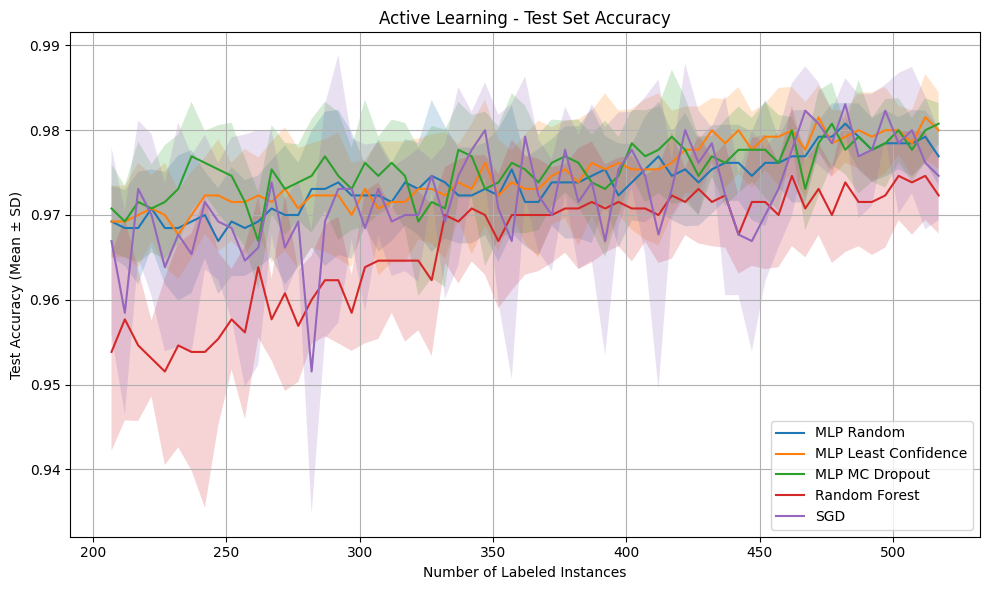

In [27]:
# ------------------------
# Plot Test Set Accuracy
# ------------------------
plt.figure(figsize=(10, 6))
for label, (_, test_scores) in results.items():
    mean = test_scores.mean(axis=0)
    std = test_scores.std(axis=0)
    x_vals = np.arange(len(mean)) * step + int(init_frac * len(X_train_full))
    
    plt.plot(x_vals, mean, label=label)
    plt.fill_between(x_vals, mean - std, mean + std, alpha=0.2)

plt.title("Active Learning - Test Set Accuracy")
plt.xlabel("Number of Labeled Instances")
plt.ylabel("Test Accuracy (Mean ± SD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

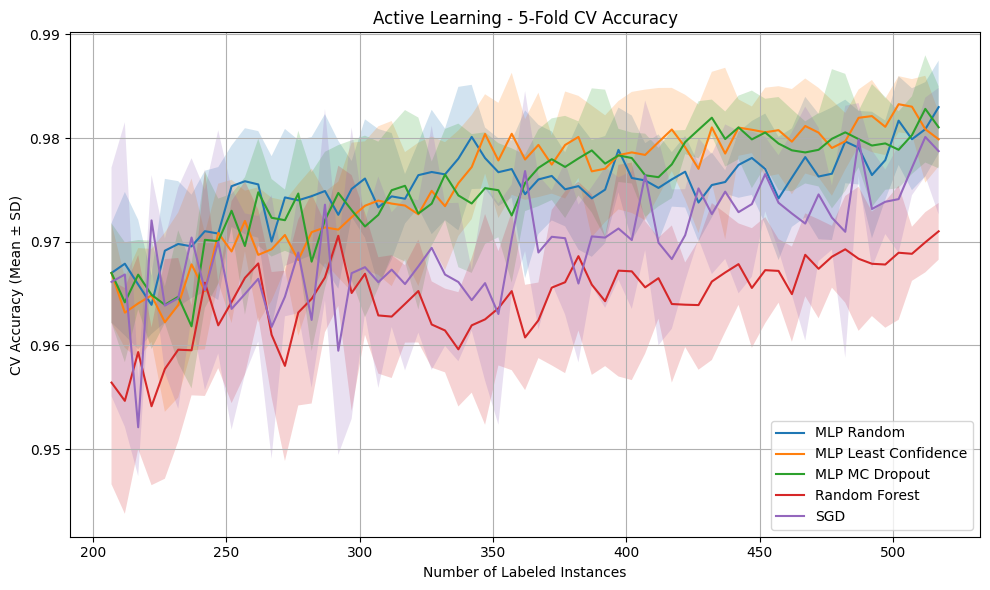

In [28]:
# ------------------------
# Plot CV Accuracy (with shape safety)
# ------------------------
plt.figure(figsize=(10, 6))
for label, (cv_scores, _) in results.items():
    mean = cv_scores.mean(axis=0)
    std = cv_scores.std(axis=0)
    x_vals = np.arange(len(mean)) * step + int(init_frac * len(X_train_full))
    
    plt.plot(x_vals, mean, label=label)
    plt.fill_between(x_vals, mean - std, mean + std, alpha=0.2)

plt.title("Active Learning - 5-Fold CV Accuracy")
plt.xlabel("Number of Labeled Instances")
plt.ylabel("CV Accuracy (Mean ± SD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [75]:
# ------------------------
# Compute Learning Efficiency
# ------------------------
def learning_efficiency(curve, threshold=0.97):
    for i, acc in enumerate(curve):
        if acc >= threshold:
            return i * step + int(init_frac * len(X_train_full))
    return None

print("\nLearning Efficiency (samples to reach 97% accuracy):")
for name, (cv_scores, _) in results.items():
    avg_curve = cv_scores.mean(axis=0)
    smoothed_curve = smooth_curve(avg_curve)
    n = learning_efficiency(smoothed_curve)
    print(f"{name}: {n if n else 'Not reached'}")


Learning Efficiency (samples to reach 97% accuracy):
MLP Random: 232
MLP Least Confidence: 247
MLP MC Dropout: 242
Random Forest: Not reached
SGD: 352


In [58]:
def plot_rf_sgd_comparison(results, step, init_frac, show='both'):
    plt.figure(figsize=(10, 6))
    colors = {
        "Random Forest": "crimson",
        "SGD": "mediumpurple"
    }

    for label, (cv_scores, test_scores) in results.items():
        if label not in ["Random Forest", "SGD"]:
            continue

        if show == 'cv':
            scores = cv_scores
            title = "5-Fold CV Accuracy"
            ylabel = "CV Accuracy"
        elif show == 'test':
            scores = test_scores
            title = "Test Set Accuracy"
            ylabel = "Test Accuracy"
        else:  # show both test and CV
            title = "Test vs CV Accuracy"
            ylabel = "Accuracy"

            mean_test = smooth_curve(test_scores.mean(axis=0))
            mean_cv = smooth_curve(cv_scores.mean(axis=0))
            x_vals = np.arange(len(mean_test)) * step + int(init_frac * len(X_train_full))

            plt.plot(x_vals, mean_test, label=f"{label} (Test)", color=colors[label], linestyle="-", linewidth=2)
            plt.plot(x_vals, mean_cv, label=f"{label} (CV)", color=colors[label], linestyle="--", linewidth=2)
            continue

        mean = smooth_curve(scores.mean(axis=0))
        std = smooth_curve(scores.std(axis=0))
        x_vals = np.arange(len(mean)) * step + int(init_frac * len(X_train_full))

        plt.plot(x_vals, mean, label=label, color=colors[label], linewidth=2)
        plt.fill_between(x_vals, mean - std, mean + std, color=colors[label], alpha=0.2)

    plt.title(f"Active Learning Performance ({title}) - RF vs SGD", fontsize=14)
    plt.xlabel("Number of Labeled Instances", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.ylim(0.95, 0.99)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

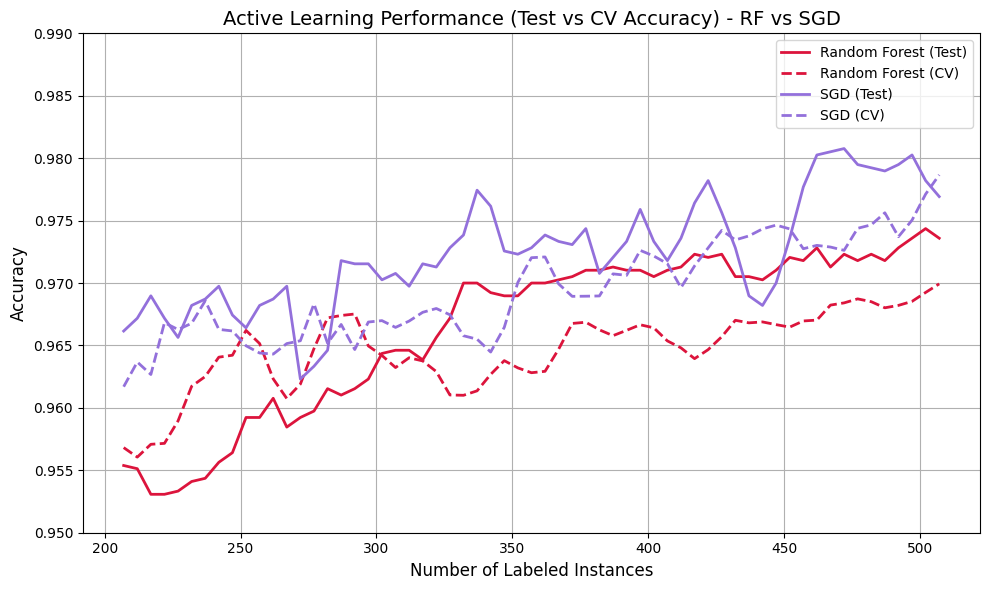

In [59]:
plot_rf_sgd_comparison(results, step, init_frac, show='both')

In [80]:
def plot_rf_sgd(results, step, init_frac, metric='cv'):
    """
    Plot Random Forest and SGD curves for CV or Test Accuracy with mean ± std.

    Parameters:
        results (dict): Dictionary of results with model name → (cv_scores, test_scores)
        step (int): Step size per active learning round
        init_frac (float): Initial labeled fraction
        metric (str): 'cv' or 'test'
    """
    assert metric in ['cv', 'test'], "metric must be 'cv' or 'test'"
    
    plt.figure(figsize=(10, 6))
    colors = {
        "Random Forest": "crimson",
        "SGD": "mediumpurple"
    }

    for label, (cv_scores, test_scores) in results.items():
        if label not in ["Random Forest", "SGD"]:
            continue

        scores = cv_scores if metric == 'cv' else test_scores
        mean = smooth_curve(scores.mean(axis=0))
        std = smooth_curve(scores.std(axis=0))
        x_vals = np.arange(len(mean)) * step + int(init_frac * len(X_train_full))

        plt.plot(x_vals, mean, label=label, color=colors[label], linewidth=2)
        plt.fill_between(x_vals, mean - std, mean + std, color=colors[label], alpha=0.2)

    plt.title(f"Active Learning - {metric.upper()} Accuracy (Random Forest & SGD)", fontsize=14)
    plt.xlabel("Number of Labeled Instances", fontsize=12)
    plt.ylabel(f"Accuracy ", fontsize=12)
    plt.ylim(0.93, 0.99)
    plt.grid(False)
    plt.legend()
    plt.tight_layout()
    plt.show()

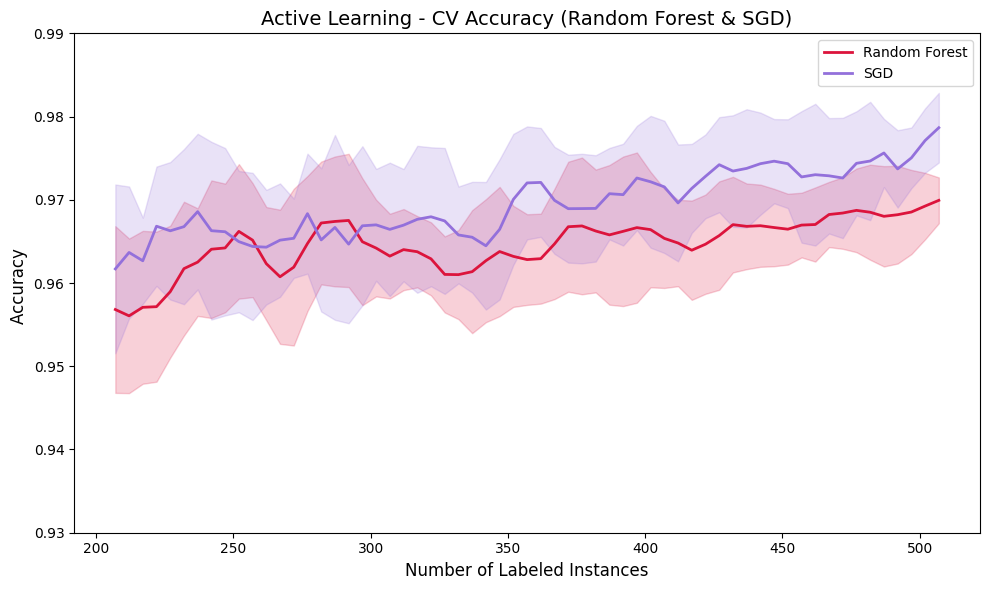

In [81]:
plot_rf_sgd(results, step=step, init_frac=init_frac, metric='cv')

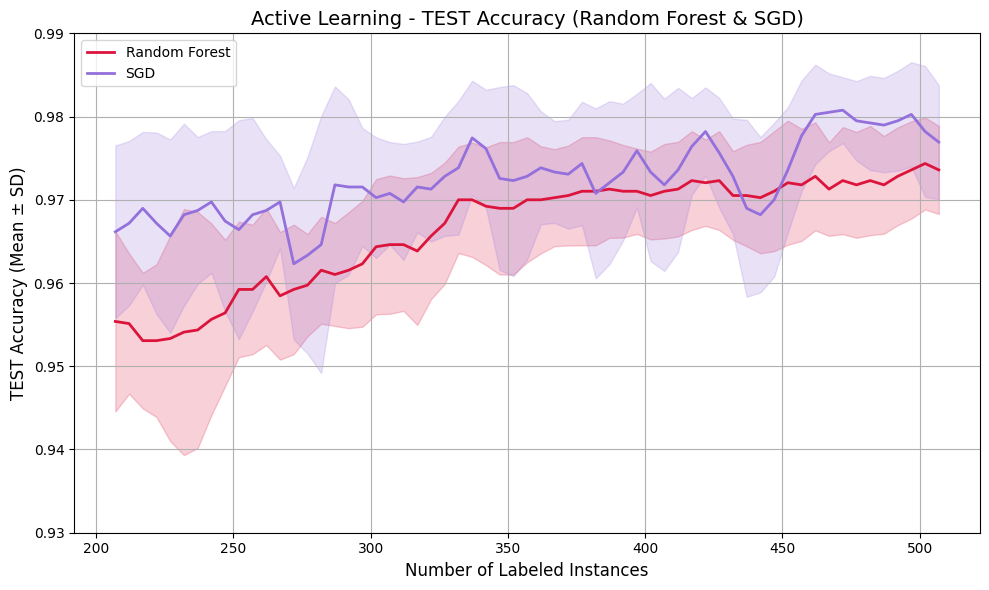

In [71]:
plot_rf_sgd(results, step=step, init_frac=init_frac, metric='test')

In [84]:
def plot_mlp(results, step, init_frac, metric='cv'):
    """
    Plot MLP Random, Least Confidence, and MC Dropout for CV or Test Accuracy.

    Parameters:
        results (dict): results[name] = (cv_scores, test_scores)
        step (int): step size per query round
        init_frac (float): initial labeled data fraction
        metric (str): 'cv' or 'test'
    """
    assert metric in ['cv', 'test'], "metric must be 'cv' or 'test'"
    
    plt.figure(figsize=(10, 6))
    colors = {
        "MLP Random": "royalblue",
        "MLP Least Confidence": "darkorange",
        "MLP MC Dropout": "green"
    }

    for label, (cv_scores, test_scores) in results.items():
        if not label.startswith("MLP"):
            continue

        scores = cv_scores if metric == 'cv' else test_scores
        mean = smooth_curve(scores.mean(axis=0))
        std = smooth_curve(scores.std(axis=0))
        x_vals = np.arange(len(mean)) * step + int(init_frac * len(X_train_full))

        plt.plot(x_vals, mean, label=label, color=colors[label], linewidth=2)
        plt.fill_between(x_vals, mean - std, mean + std, color=colors[label], alpha=0.2)

    plt.title(f"Active Learning - {metric.upper()} Accuracy (MLP Models)", fontsize=14)
    plt.xlabel("Number of Labeled Instances", fontsize=12)
    plt.ylabel(f" Accuracy", fontsize=12)
    plt.ylim(0.93, 0.99)
    plt.grid(False)
    plt.legend()
    plt.tight_layout()
    plt.show()

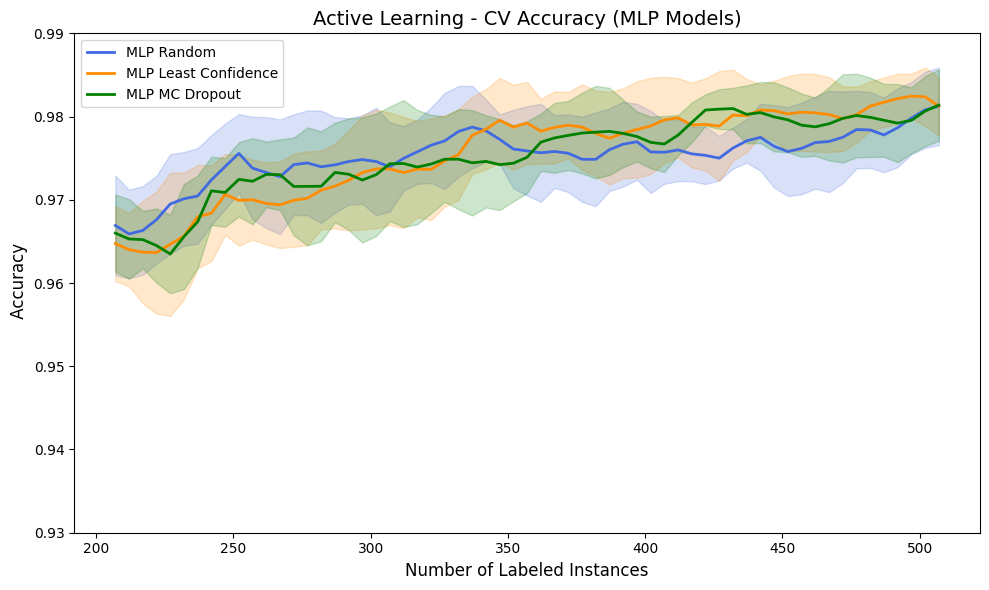

In [85]:
plot_mlp(results, step=step, init_frac=init_frac, metric='cv')

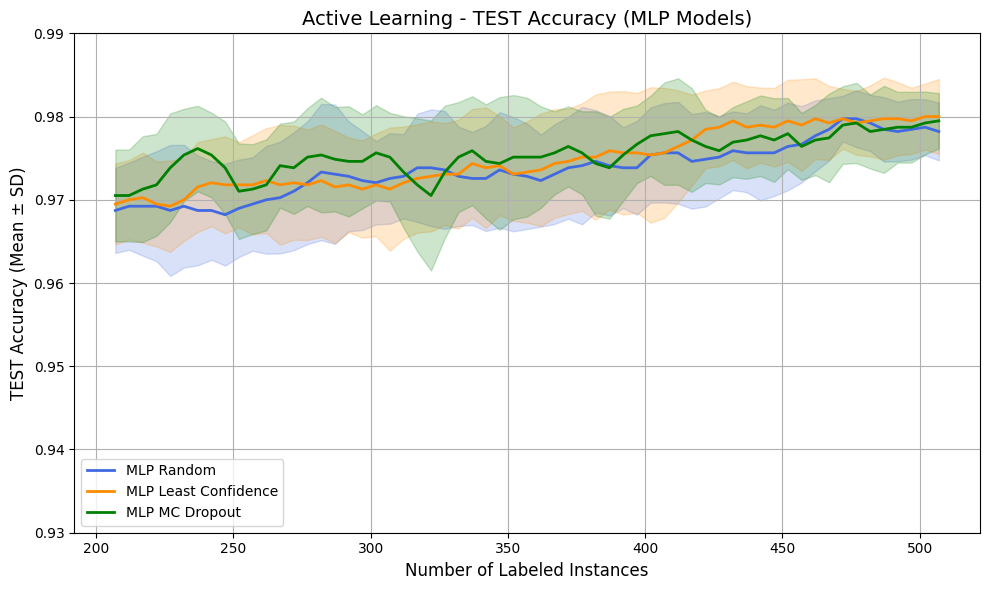

In [74]:
plot_mlp(results, step=step, init_frac=init_frac, metric='test')